# Introducción al clustering

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import single, cophenet
from scipy.spatial.distance import pdist, squareform

In [3]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [4]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine = fetch_ucirepo(id=109) 
  
# data (as pandas dataframes) 
X = wine.data.features 
y = wine.data.targets 
  
# metadata 
print(wine.metadata) 
  
# variable information 
print(wine.variables) 


{'uci_id': 109, 'name': 'Wine', 'repository_url': 'https://archive.ics.uci.edu/dataset/109/wine', 'data_url': 'https://archive.ics.uci.edu/static/public/109/data.csv', 'abstract': 'Using chemical analysis to determine the origin of wines', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 178, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1992, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C5PC7J', 'creators': ['Stefan Aeberhard', 'M. Forina'], 'intro_paper': {'ID': 246, 'type': 'NATIVE', 'title': 'Comparative analysis of statistical pattern recognition methods in high dimensional settings', 'authors': 'S. Aeberhard, D. Coomans, O. Vel', 'venue': 'Pattern Recognition', 'year': 1994, 'journal': None, 'DOI': '10.1016/0031-3203(94)90145-7', 'URL': 'https:

### Exploratory data analysis

In [5]:
# Combine into one DataFrame
df = pd.concat([X, y], axis=1)

df.head()

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [6]:
df.shape

(178, 14)

In [7]:
df.dtypes

Alcohol                         float64
Malicacid                       float64
Ash                             float64
Alcalinity_of_ash               float64
Magnesium                         int64
Total_phenols                   float64
Flavanoids                      float64
Nonflavanoid_phenols            float64
Proanthocyanins                 float64
Color_intensity                 float64
Hue                             float64
0D280_0D315_of_diluted_wines    float64
Proline                           int64
class                             int64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Alcohol                       178 non-null    float64
 1   Malicacid                     178 non-null    float64
 2   Ash                           178 non-null    float64
 3   Alcalinity_of_ash             178 non-null    float64
 4   Magnesium                     178 non-null    int64  
 5   Total_phenols                 178 non-null    float64
 6   Flavanoids                    178 non-null    float64
 7   Nonflavanoid_phenols          178 non-null    float64
 8   Proanthocyanins               178 non-null    float64
 9   Color_intensity               178 non-null    float64
 10  Hue                           178 non-null    float64
 11  0D280_0D315_of_diluted_wines  178 non-null    float64
 12  Proline                       178 non-null    int64  
 13  class

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malicacid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
Color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [10]:
df[df==0].count() / df.count()

Alcohol                         0.0
Malicacid                       0.0
Ash                             0.0
Alcalinity_of_ash               0.0
Magnesium                       0.0
Total_phenols                   0.0
Flavanoids                      0.0
Nonflavanoid_phenols            0.0
Proanthocyanins                 0.0
Color_intensity                 0.0
Hue                             0.0
0D280_0D315_of_diluted_wines    0.0
Proline                         0.0
class                           0.0
dtype: float64

In [11]:
df.head(4)

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1


In [12]:
df.nunique()

Alcohol                         126
Malicacid                       133
Ash                              79
Alcalinity_of_ash                63
Magnesium                        53
Total_phenols                    97
Flavanoids                      132
Nonflavanoid_phenols             39
Proanthocyanins                 101
Color_intensity                 132
Hue                              78
0D280_0D315_of_diluted_wines    122
Proline                         121
class                             3
dtype: int64

In [13]:
print('Existen',df.isnull().sum().sum(),'valores no definidos')

Existen 0 valores no definidos


In [14]:
print(df.columns[df.isnull().any()])

Index([], dtype='object')


In [15]:
df[df.columns[df.isnull().any()]].isnull().sum()

Series([], dtype: float64)

In [16]:
df[df.columns[df.isnull().any()]].isnull().sum()*100/df.shape[0]

Series([], dtype: float64)

In [17]:
print('Duplicate records:')
print(df[df.duplicated()])

Duplicate records:
Empty DataFrame
Columns: [Alcohol, Malicacid, Ash, Alcalinity_of_ash, Magnesium, Total_phenols, Flavanoids, Nonflavanoid_phenols, Proanthocyanins, Color_intensity, Hue, 0D280_0D315_of_diluted_wines, Proline, class]
Index: []


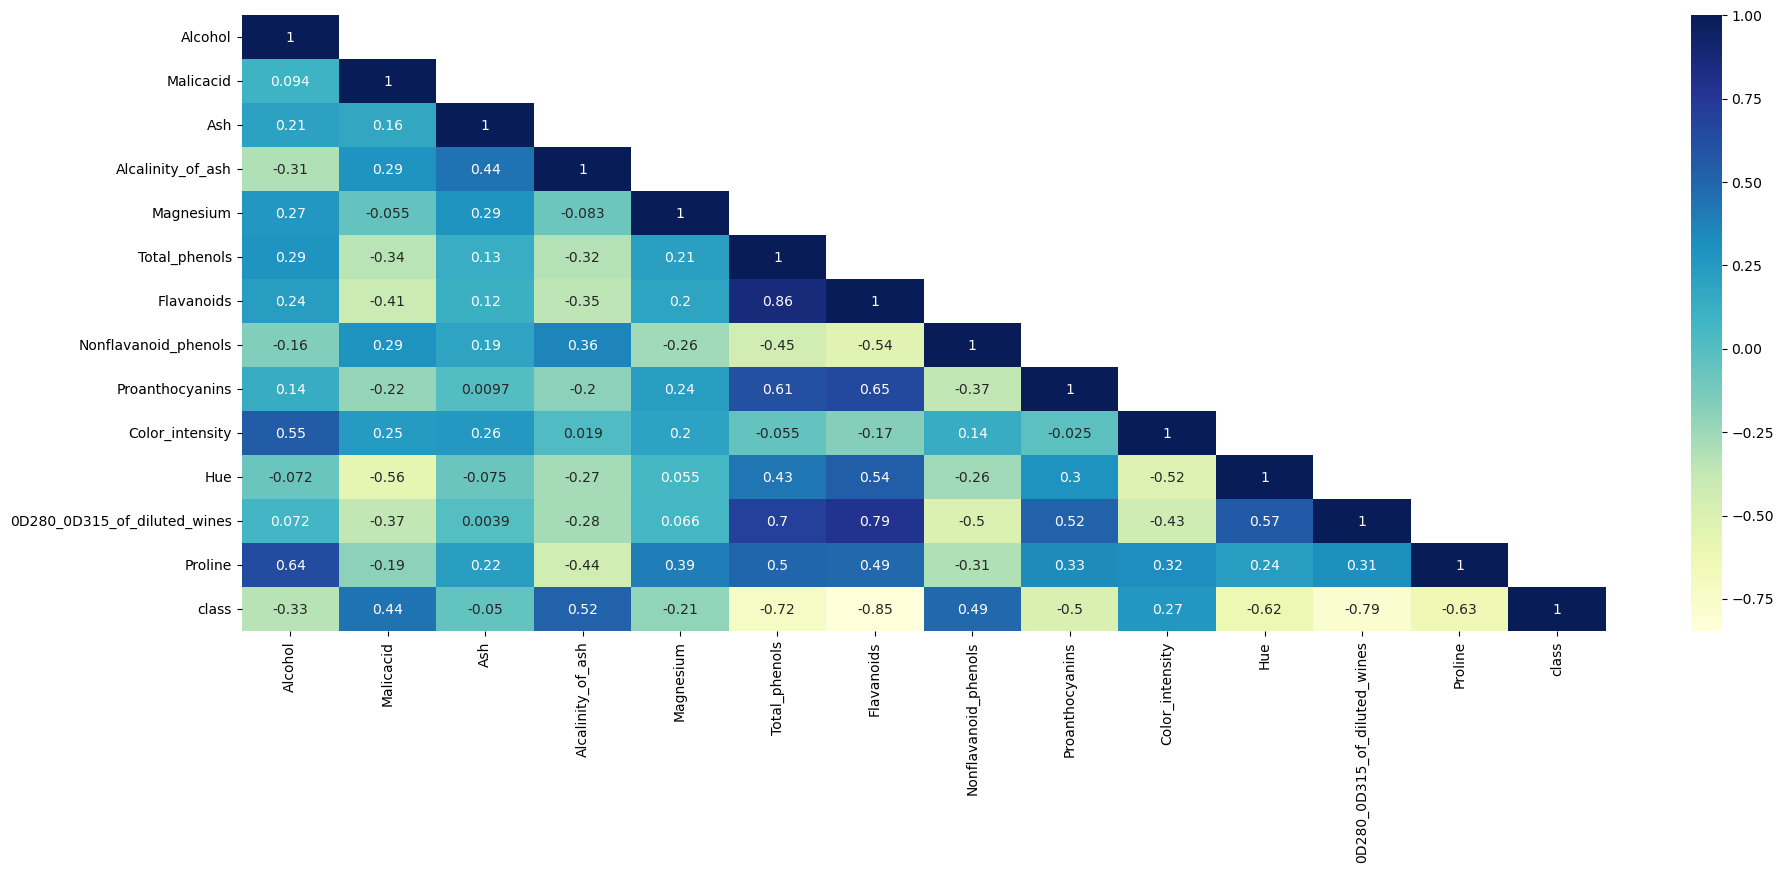

In [18]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22,8))
corr_df = corr = df.corr(numeric_only=True,method='pearson')
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap = sns.heatmap(df_lt, cmap='YlGnBu',annot=True)

In [19]:
numerics = ['int16', 'int32','int64','float64']
df.select_dtypes(include=numerics).sample(5)

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,class
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.320000,1.04,2.93,735,1
44,13.05,1.77,2.10,17.0,107,3.00,3.00,0.28,2.03,5.040000,0.88,3.35,885,1
171,12.77,2.39,2.28,19.5,86,1.39,0.51,0.48,0.64,9.899999,0.57,1.63,470,3
73,12.99,1.67,2.60,30.0,139,3.30,2.89,0.21,1.96,3.350000,1.31,3.50,985,2
139,12.84,2.96,2.61,24.0,101,2.32,0.60,0.53,0.81,4.920000,0.89,2.15,590,3


In [20]:
cols_num = df.columns[[np.issubdtype(dt,np.number) for dt in df.dtypes]]

In [21]:
print(cols_num)
print(len(cols_num))

Index(['Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium',
       'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols',
       'Proanthocyanins', 'Color_intensity', 'Hue',
       '0D280_0D315_of_diluted_wines', 'Proline', 'class'],
      dtype='object')
14


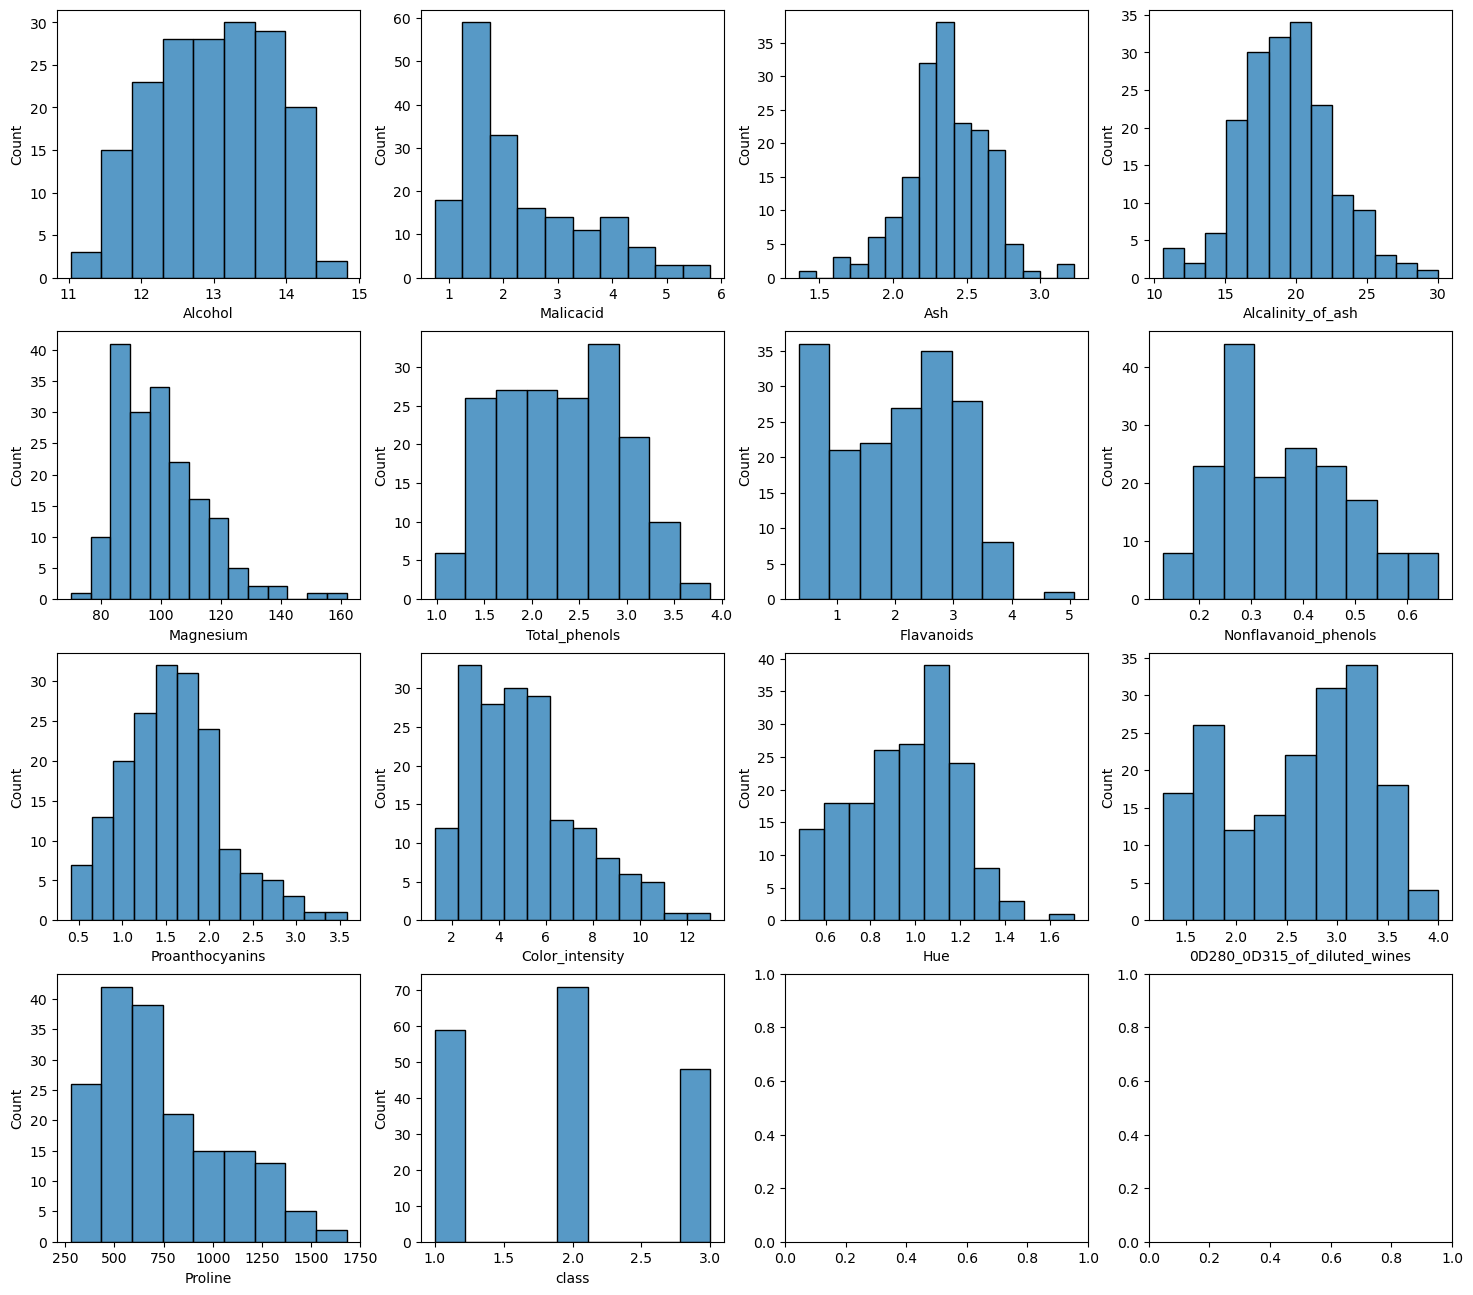

In [22]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18,16))
for i, column in enumerate(cols_num):
    sns.histplot(df[column],ax=axes[i//4,i%4],kde=False)

Text(0.5, 1.0, 'Box-plot de Variables')

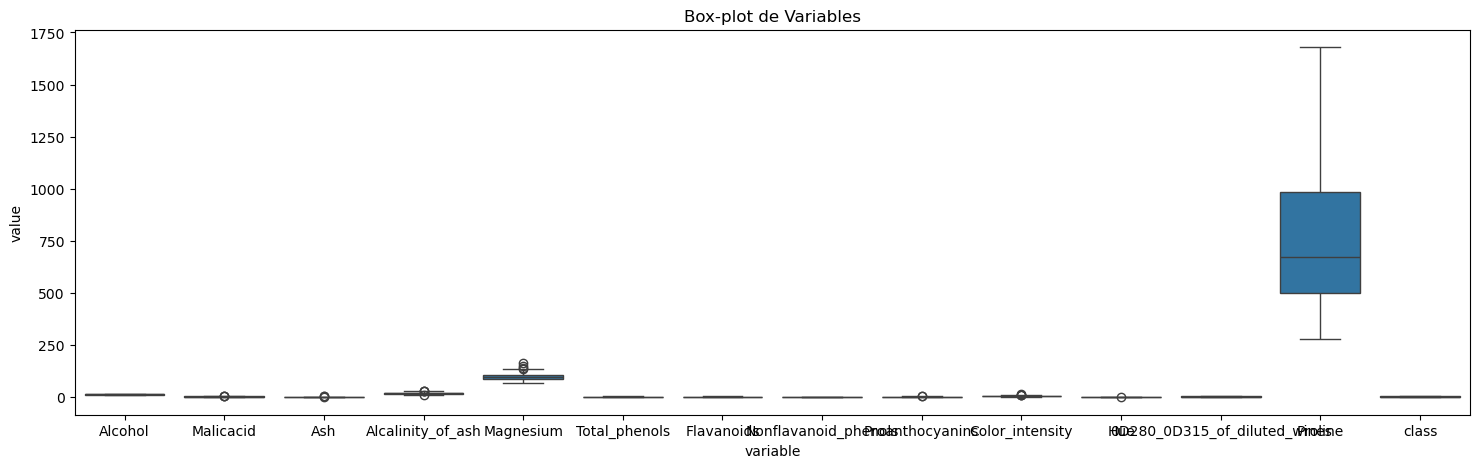

In [23]:
plt.figure(figsize=(18,5))
sns.boxplot(x='variable',y='value',data=pd.melt(df[cols_num])).set_title('Box-plot de Variables')

In [24]:
df2 = df.copy()
df2.head(1)

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,class
0,14.23,1.71,2.43,15.6,127,2.8,3.06,0.28,2.29,5.64,1.04,3.92,1065,1


In [25]:
df3 = df.copy()
df3.head(1)

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,class
0,14.23,1.71,2.43,15.6,127,2.8,3.06,0.28,2.29,5.64,1.04,3.92,1065,1


In [26]:
from scipy.stats import pearsonr

def reg_coef(x,y, label=None, color= None,**kwargs):
    ax = plt.gca()
    r,p = pearsonr(x,y)
    ax.annotate('r={:.2}'.format(r),xy=(0.5,0.5),xycoords='axes fraction',ha='center',fontsize=15)
    ax.set_axis_off()

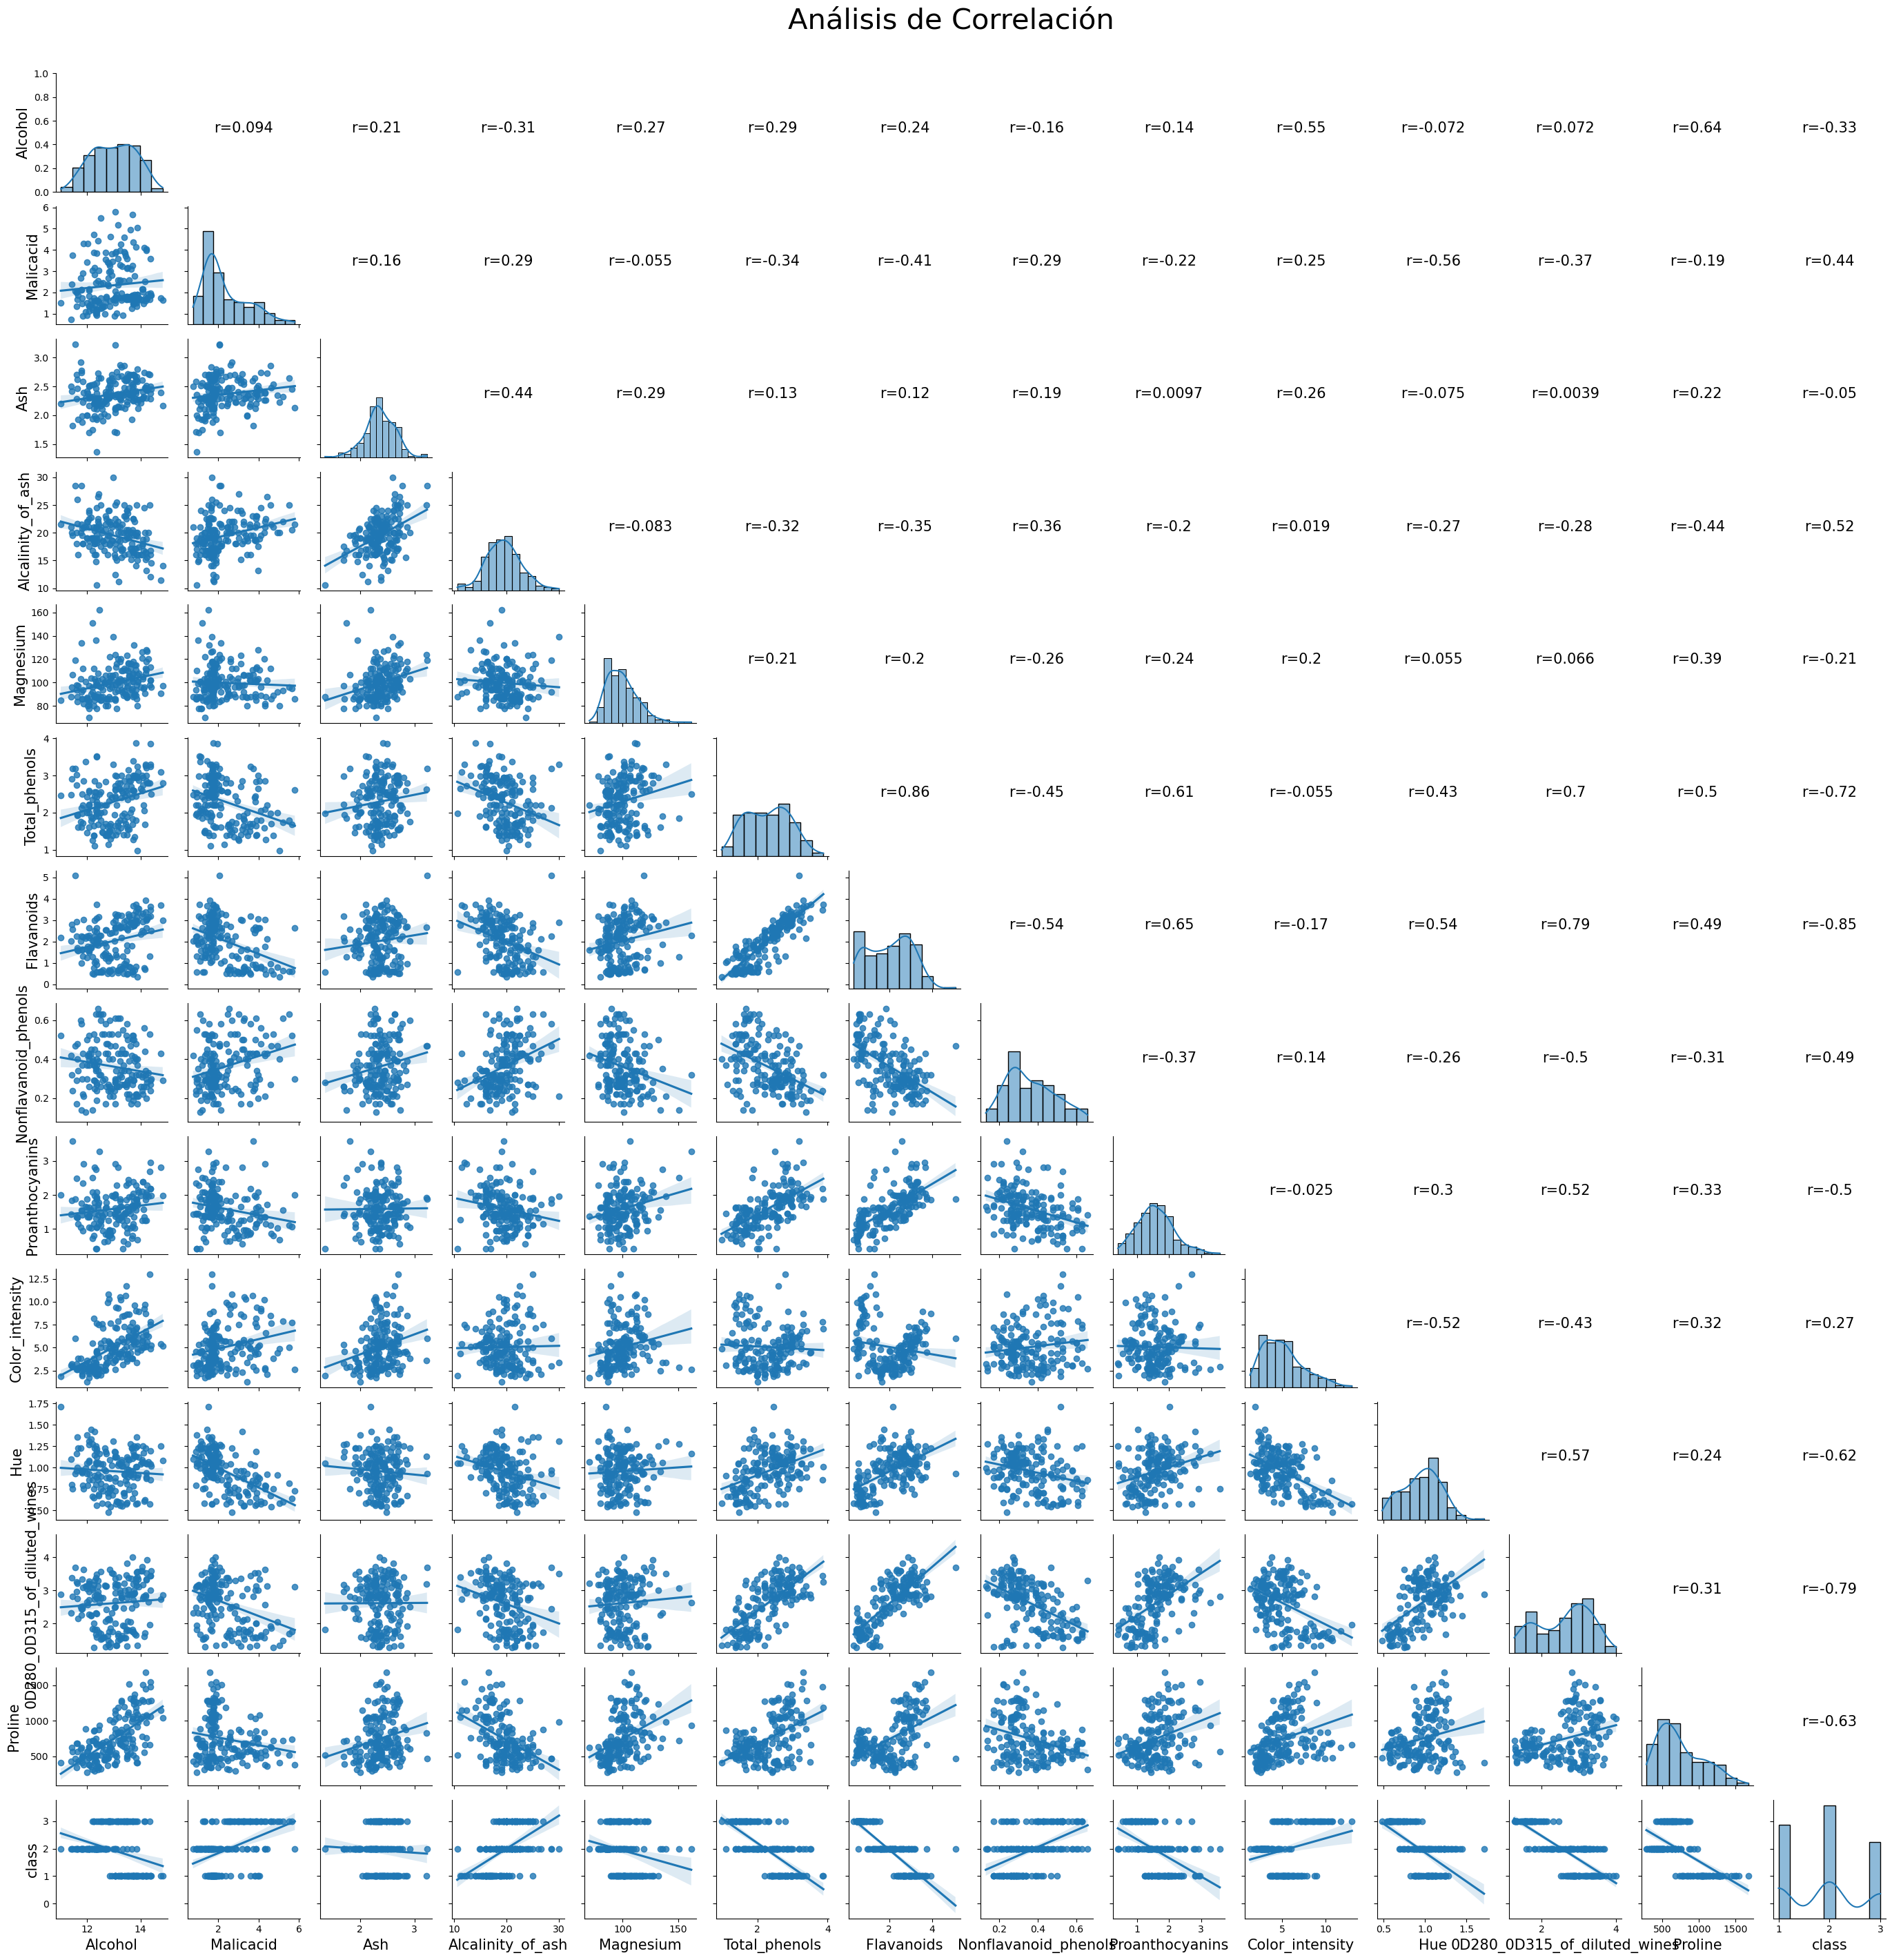

In [27]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.rcParams['axes.labelsize'] = 15

g = sns.PairGrid(df2, height=2)

g.map_diag(sns.histplot, kde=True)
g.map_lower(sns.regplot)
g.map_upper(reg_coef, fontsize=20, cmap=plt.get_cmap('GnBu'))

g.fig.suptitle('Análisis de Correlación', fontsize=30, y=1.02)

plt.show()

In [28]:
from scipy.stats import zscore
df2 = df2.apply(zscore)

In [29]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,-8.382808e-16,1.002821,-2.434235,-0.788245,0.061000,0.836129,2.259772
Malicacid,178.0,-1.197544e-16,1.002821,-1.432983,-0.658749,-0.423112,0.669793,3.109192
Ash,178.0,-8.370333e-16,1.002821,-3.679162,-0.572122,-0.023821,0.698109,3.156325
Alcalinity_of_ash,178.0,-3.991813e-17,1.002821,-2.671018,-0.689137,0.001518,0.602088,3.154511
Magnesium,178.0,-3.991813e-17,1.002821,-2.088255,-0.824415,-0.122282,0.509638,4.371372
Total_phenols,178.0,0.000000e+00,1.002821,-2.107246,-0.885468,0.095960,0.808997,2.539515
Flavanoids,178.0,-3.991813e-16,1.002821,-1.695971,-0.827539,0.106150,0.849085,3.062832
Nonflavanoid_phenols,178.0,3.592632e-16,1.002821,-1.868234,-0.740141,-0.176095,0.609541,2.402403
Proanthocyanins,178.0,-1.197544e-16,1.002821,-2.069034,-0.597284,-0.062898,0.629175,3.485073
Color_intensity,178.0,2.494883e-17,1.002821,-1.634288,-0.795103,-0.159225,0.493956,3.435432


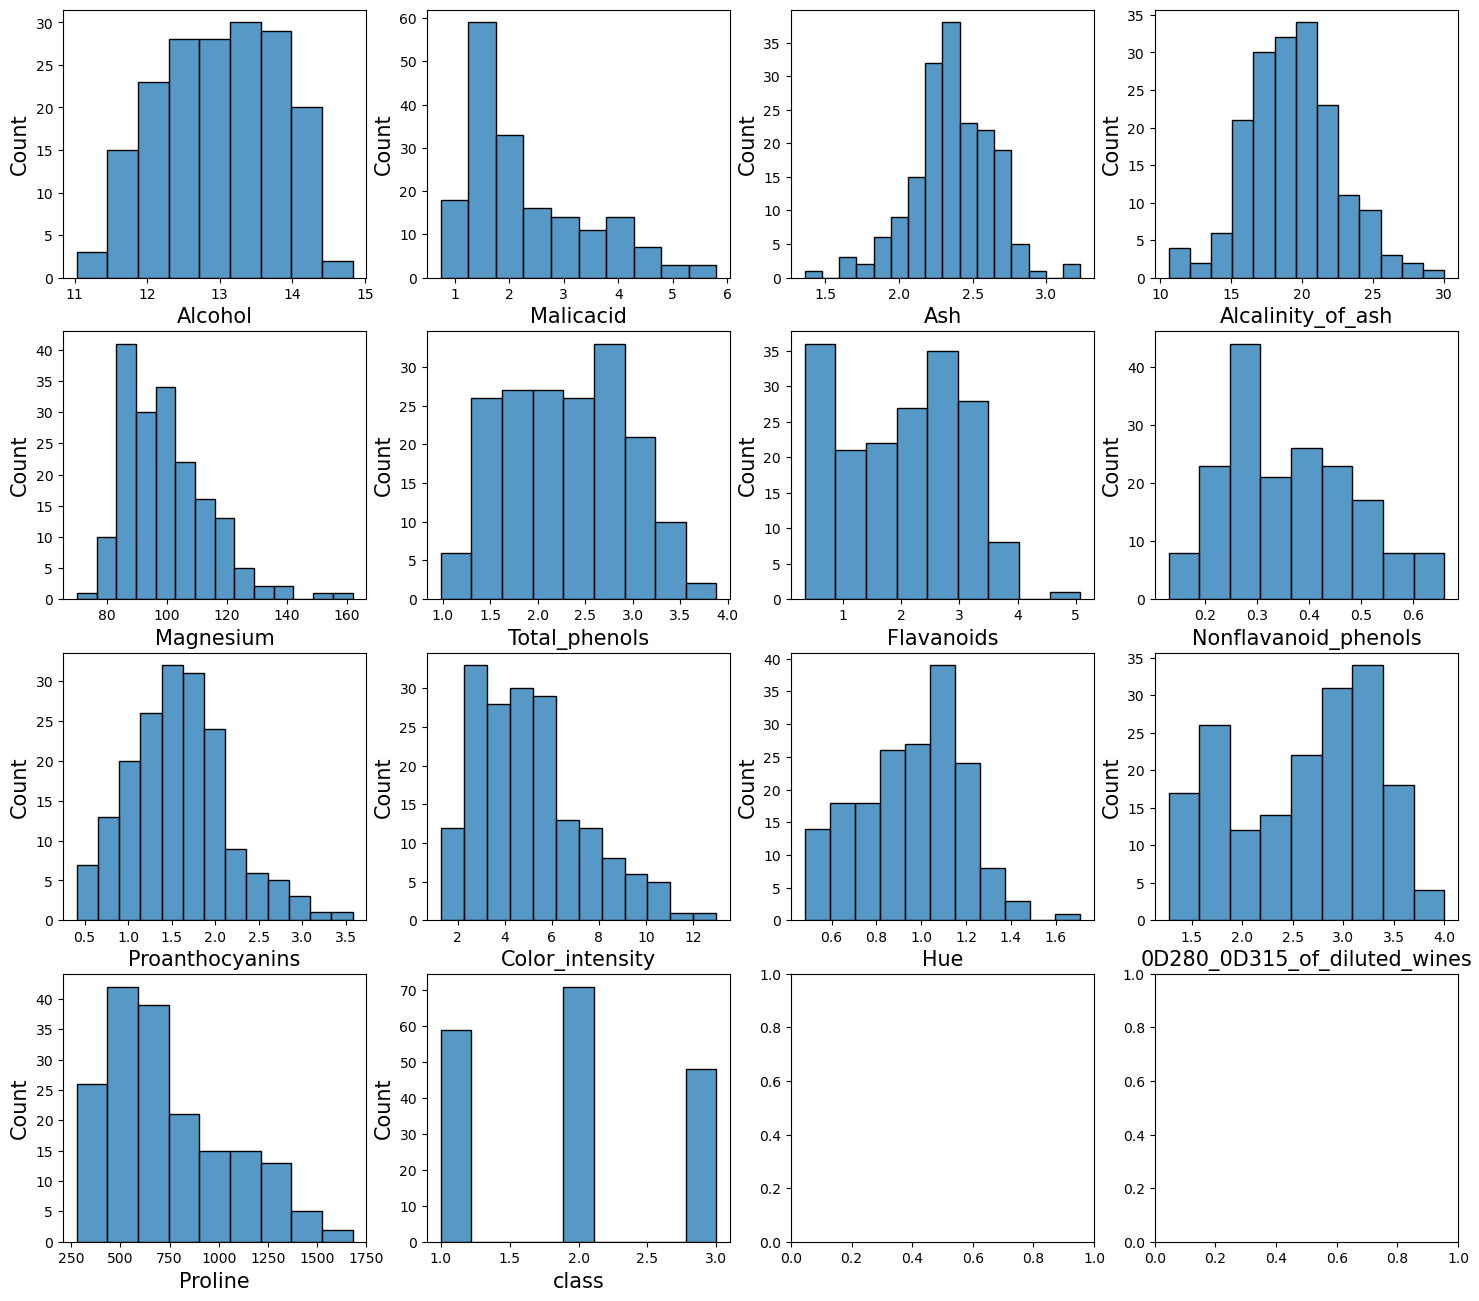

In [30]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18,16))
for i, column in enumerate(cols_num):
    sns.histplot(df[column],ax=axes[i//4,i%4],kde=False)

# Modelo de Clustering K-Means

Text(0.5, 1.0, 'Resultados KMeans')

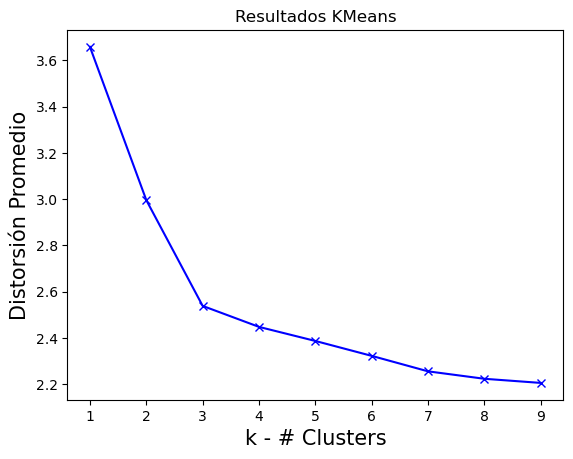

In [32]:
from scipy.spatial.distance import cdist
clusters = range(1,10)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k)
    model.fit(df2)
    prediction = model.predict(df2)
    meanDistortions.append(sum(np.min(cdist(df2,model.cluster_centers_,'euclidean'),axis=1))/df2.shape[0])

plt.plot(cluster,meanDistortions,'bx-')
plt.xlabel('k - # Clusters')
plt.ylabel('Distorsión Promedio')
plt.title('Resultados KMeans')


In [33]:
prediction

array([1, 1, 1, 1, 3, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 1, 1, 1, 3,
       1, 3, 3, 3, 1, 1, 3, 1, 3, 1, 1, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 3,
       1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 6, 6, 6, 6, 4, 0, 4,
       4, 6, 6, 6, 6, 4, 7, 3, 4, 6, 6, 6, 6, 7, 4, 4, 0, 8, 4, 6, 0, 0,
       0, 0, 0, 0, 0, 4, 4, 3, 3, 4, 4, 4, 6, 6, 7, 6, 7, 0, 7, 0, 7, 4,
       4, 7, 0, 0, 7, 0, 7, 7, 2, 7, 7, 3, 7, 7, 7, 7, 7, 0, 7, 7, 2, 2,
       2, 2, 2, 2, 2, 8, 2, 8, 2, 2, 8, 8, 2, 2, 2, 8, 8, 8, 8, 8, 8, 8,
       2, 8, 8, 8, 5, 5, 8, 8, 8, 2, 8, 8, 8, 8, 8, 8, 2, 2, 8, 8, 8, 8,
       8, 8], dtype=int32)

In [35]:
kmeans =  KMeans(n_clusters=3, n_init = 15, random_state=1)
kmeans.fit(df2)

KMeans(n_clusters=3, n_init=15, random_state=1)

In [36]:
prediction

array([1, 1, 1, 1, 3, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 1, 1, 1, 3,
       1, 3, 3, 3, 1, 1, 3, 1, 3, 1, 1, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 3,
       1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 6, 6, 6, 6, 4, 0, 4,
       4, 6, 6, 6, 6, 4, 7, 3, 4, 6, 6, 6, 6, 7, 4, 4, 0, 8, 4, 6, 0, 0,
       0, 0, 0, 0, 0, 4, 4, 3, 3, 4, 4, 4, 6, 6, 7, 6, 7, 0, 7, 0, 7, 4,
       4, 7, 0, 0, 7, 0, 7, 7, 2, 7, 7, 3, 7, 7, 7, 7, 7, 0, 7, 7, 2, 2,
       2, 2, 2, 2, 2, 8, 2, 8, 2, 2, 8, 8, 2, 2, 2, 8, 8, 8, 8, 8, 8, 8,
       2, 8, 8, 8, 5, 5, 8, 8, 8, 2, 8, 8, 8, 8, 8, 8, 2, 2, 8, 8, 8, 8,
       8, 8], dtype=int32)

In [37]:
kmeans = KMeans(n_clusters=3,n_init=15,random_state=1)
kmeans.fit(df2)

KMeans(n_clusters=3, n_init=15, random_state=1)

In [38]:
centroids = kmeans.cluster_centers_
centroids

array([[ 0.87809728, -0.30457633,  0.31894179, -0.66452366,  0.56488825,
         0.87650546,  0.94363903, -0.58558981,  0.58178294,  0.16718842,
         0.48372814,  0.76705349,  1.15834713, -1.17152057],
       [ 0.18654314,  0.90497145,  0.24921026,  0.58370348, -0.05063539,
        -0.988557  , -1.23619475,  0.71684172, -0.74960756,  0.98849829,
        -1.19129878, -1.30153966, -0.38004461,  1.34745816],
       [-0.9221257 , -0.3788889 , -0.46568753,  0.17550695, -0.47025072,
        -0.07393442,  0.04428767,  0.0087608 ,  0.01826487, -0.86227808,
         0.42450329,  0.24978206, -0.76524984,  0.07996036]])

In [40]:
centroid_df = pd.DataFrame(centroids,columns=list(df2))
centroid_df

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,class
0,0.878097,-0.304576,0.318942,-0.664524,0.564888,0.876505,0.943639,-0.585590,0.581783,0.167188,0.483728,0.767053,1.158347,-1.171521
1,0.186543,0.904971,0.249210,0.583703,-0.050635,-0.988557,-1.236195,0.716842,-0.749608,0.988498,-1.191299,-1.301540,-0.380045,1.347458
2,-0.922126,-0.378889,-0.465688,0.175507,-0.470251,-0.073934,0.044288,0.008761,0.018265,-0.862278,0.424503,0.249782,-0.765250,0.079960


In [42]:
df_labels = pd.DataFrame(kmeans.labels_,columns=list(['labels']))
df_labels['labels'] = df_labels['labels'].astype('category')

In [43]:
df_labeled = df2.join(df_labels)

In [44]:
df_labeled.columns

Index(['Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium',
       'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols',
       'Proanthocyanins', 'Color_intensity', 'Hue',
       '0D280_0D315_of_diluted_wines', 'Proline', 'class', 'labels'],
      dtype='object')

In [46]:
df_labeled.head(20)

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,class,labels
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009,-1.213944,0
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242,-1.213944,0
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148,-1.213944,0
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574,-1.213944,0
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874,-1.213944,0
5,1.481555,-0.517367,0.305159,-1.289707,0.860705,1.562093,1.366128,-0.176095,0.664217,0.731870,0.406051,0.336606,2.239039,-1.213944,0
6,1.716255,-0.418624,0.305159,-1.469878,-0.262708,0.328298,0.492677,-0.498407,0.681738,0.083015,0.274431,1.367689,1.729520,-1.213944,0
7,1.308617,-0.167278,0.890014,-0.569023,1.492625,0.488531,0.482637,-0.417829,-0.597284,-0.003499,0.449924,1.367689,1.745442,-1.213944,0
8,2.259772,-0.625086,-0.718336,-1.650049,-0.192495,0.808997,0.954502,-0.578985,0.681738,0.061386,0.537671,0.336606,0.949319,-1.213944,0
9,1.061565,-0.885409,-0.352802,-1.049479,-0.122282,1.097417,1.125176,-1.143031,0.453967,0.935177,0.230557,1.325316,0.949319,-1.213944,0


In [47]:
df_labeled['labels'].value_counts()

labels
2    68
0    61
1    49
Name: count, dtype: int64

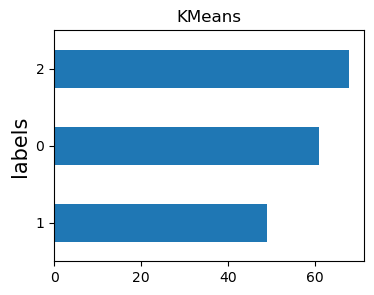

In [53]:
fig, ax = plt.subplots(figsize=(4,3))

pd.value_counts(df_labeled['labels']) \
    .sort_values(ascending=True) \
    .plot(kind='barh', ax=ax)

ax.set_title('KMeans')
plt.show()

Text(0.5, 0.98, 'Configuración de Clusters por Variable (KMeans)')

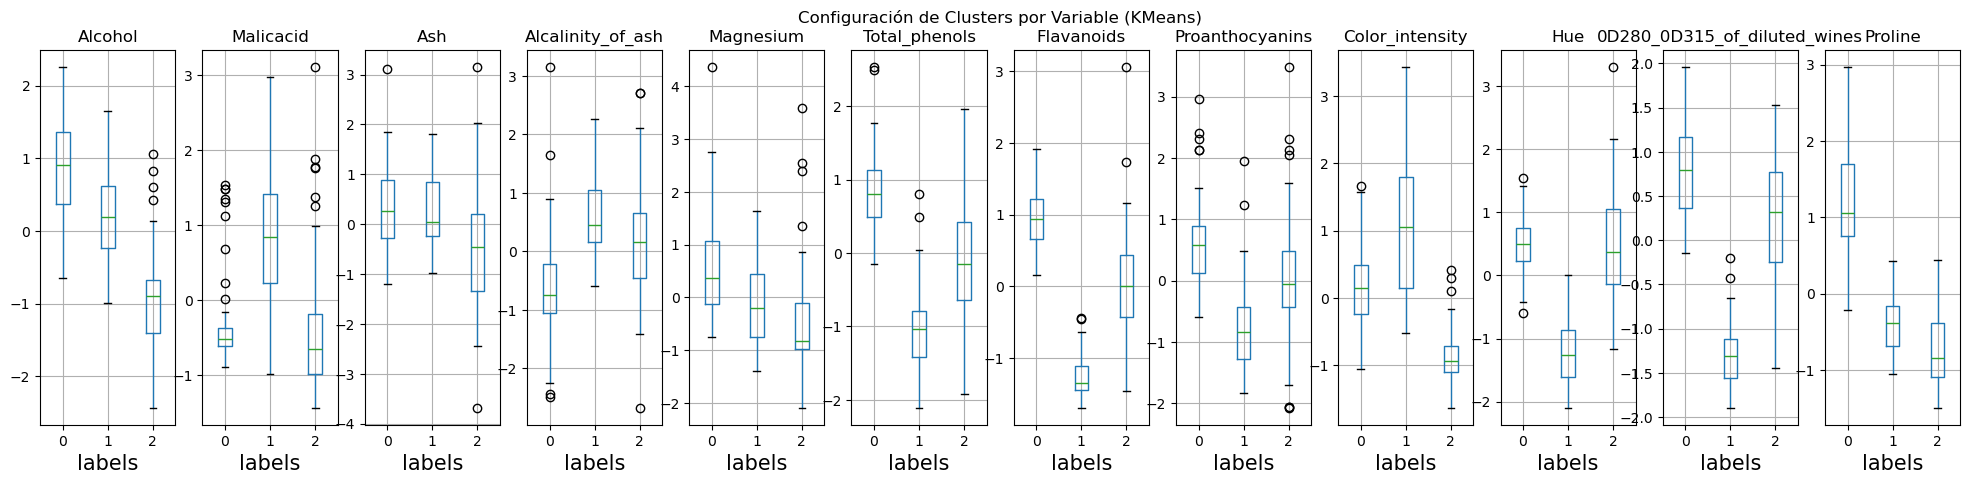

In [62]:
fig, ax = plt.subplots(1,12, figsize=(24,5))
df_labeled.boxplot('Alcohol','labels',ax=ax[0])
df_labeled.boxplot('Malicacid','labels',ax=ax[1])
df_labeled.boxplot('Ash','labels',ax=ax[2])
df_labeled.boxplot('Alcalinity_of_ash','labels',ax=ax[3])
df_labeled.boxplot('Magnesium','labels',ax=ax[4])
df_labeled.boxplot('Total_phenols','labels',ax=ax[5])
df_labeled.boxplot('Flavanoids','labels',ax=ax[6])
df_labeled.boxplot('Proanthocyanins','labels',ax=ax[7])
df_labeled.boxplot('Color_intensity','labels',ax=ax[8])
df_labeled.boxplot('Hue','labels',ax=ax[9])
df_labeled.boxplot('0D280_0D315_of_diluted_wines','labels',ax=ax[10])
df_labeled.boxplot('Proline','labels',ax=ax[11])
fig.suptitle('Configuración de Clusters por Variable (KMeans)')

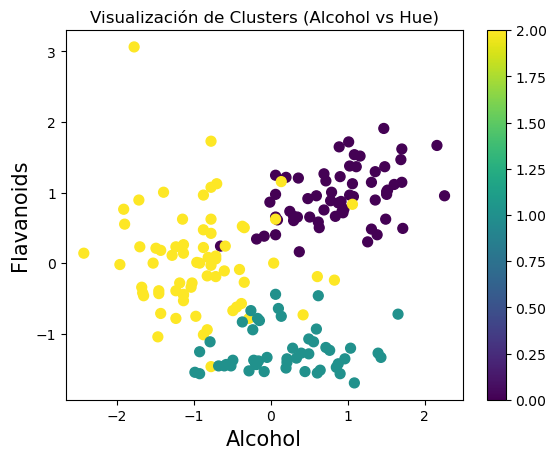

In [63]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['Alcohol'],df_labeled['Flavanoids'],c=df_labeled['labels'],s=50)
ax.set_title('Visualización de Clusters (Alcohol vs Hue)')
ax.set_xlabel('Alcohol')
ax.set_ylabel('Flavanoids')
plt.colorbar(scatter)

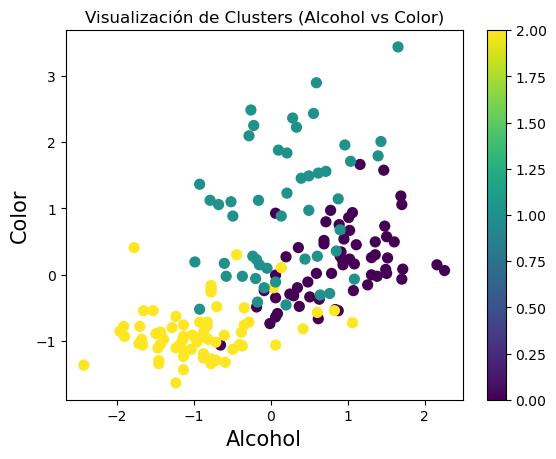

In [65]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['Alcohol'],df_labeled['Color_intensity'],c=df_labeled['labels'],s=50)
ax.set_title('Visualización de Clusters (Alcohol vs Color)')
ax.set_xlabel('Alcohol')
ax.set_ylabel('Color')
plt.colorbar(scatter)

# Hierarchical Clustering


In [66]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z =  linkage(df2, 'average',metric='euclidean')
Z.shape

(177, 4)

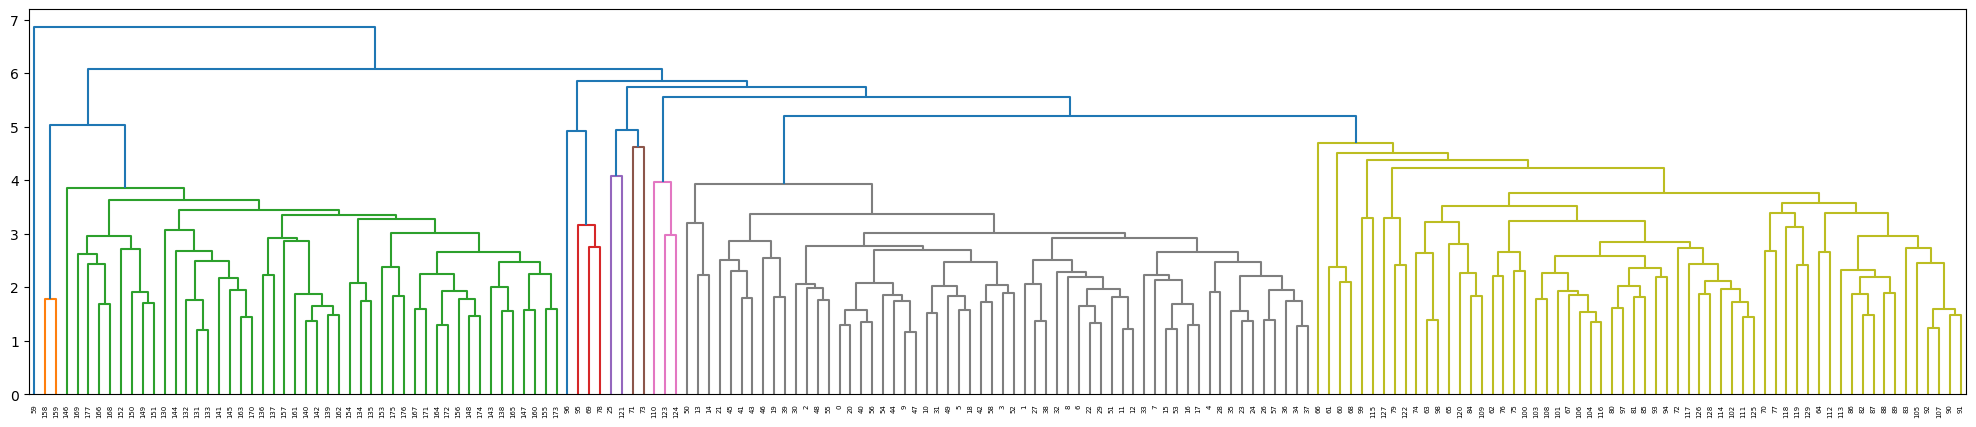

In [67]:
plt.figure(figsize=(25,5))
dendrogram(Z)
plt.show()

In [68]:
c, coph_dists = cophenet(Z,pdist(df2))
print('Cophenetic Coefficient:', format(c,'.4f'))

Cophenetic Coefficient: 0.7825


In [69]:
sil_df = pd.DataFrame({},columns=['Model','n_clusters','score'],index=None)

In [75]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

results = []

for n_clusters in range(2, 10):
    clusterer = KMeans(n_clusters=n_clusters, random_state=1, n_init='auto')
    labels = clusterer.fit_predict(df2)

    score = silhouette_score(df2, labels)

    results.append({
        'Model': 'KMeans',
        'n_clusters': n_clusters,
        'score': score
    })

sil_df = pd.DataFrame(results)

Text(0.5, 1.0, 'Silhouette Score')

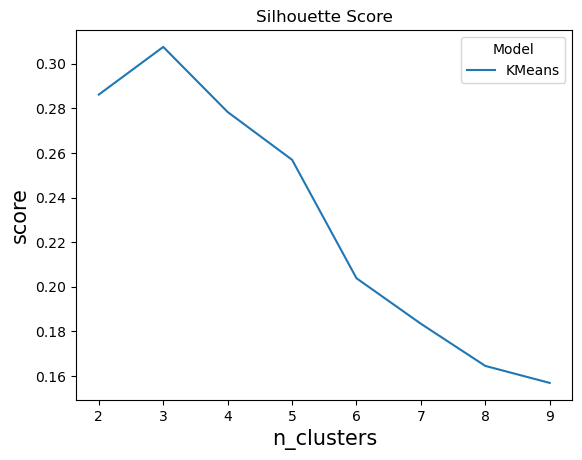

In [76]:
sns.lineplot(data = sil_df, x='n_clusters', y='score', hue='Model', style='Model', ci=None).set_title('Silhouette Score')